---
title: "Power Plants, Pollution, and Pixels"
author: "Devansh Lodha"
date: "2025-06-09"
description: "We'll analyze global power plants and use Google Earth Engine to build a machine learning model that can see pollution from space. We collect and use features from multiple satellites to accurately detect when a power plant is active."
categories: [computer vision, data analysis, code]
image: "energy_cover.jpg"
jupyter: python3
format: html
---

_This is based on the tutorial conducted by [Alok Talekar](https://research.google/people/106902/?&type=google) (Google Research) at the AI for Social Good, ACM India Summer School 2025_

Power plants are the backbone of our modern world, providing the energy that lights up our homes, powers our industries, and connects our communities. But this energy comes at a cost. The environmental impact of power generation, particularly from fossil fuels, is one of the most significant challenges of our time. Understanding this impact is the first step toward a sustainable future.

In this post, we'll embark on a data-driven journey to explore the world of power generation. We will use two key datasets:

1.  The **WRI Global Power Plant Database**, a comprehensive, open-source database of power plants around the world.
2.  The **U.S. Environmental Protection Agency (EPA) Hourly Emissions Data**, which provides detailed information about the emissions of U.S. power plants.

We'll start by exploring these datasets to get a sense of the global and U.S. energy landscape. We'll identify which countries are most reliant on coal, pinpoint the cleanest and most polluting coal plants in the U.S., and investigate their operational patterns.

In the second half of our analysis, we'll bring in a third powerful tool: **Google Earth Engine**. We will attempt to use satellite imagery to predict a power plant's emissions and even determine if it's running or not.

Let's get started!

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geodatasets
import ee
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize Google Earth Engine
# This may require authentication if you haven't used it before.

ee.Initialize(project="acm-summer-school-2025")
print("Google Earth Engine Initialized Successfully!")


# Load the datasets
# The Global Power Plant Database from WRI
power_plants_df = pd.read_csv('https://raw.githubusercontent.com/wri/global-power-plant-database/refs/heads/master/output_database/global_power_plant_database.csv')

# The EPA hourly emissions data for Q1 2024
# Note: The DtypeWarning indicates that some columns have mixed data types.
# For our analysis, this is acceptable, but in a production environment, you might want to specify dtypes on load.
emissions_df = pd.read_csv('emissions-hourly-2024-q1.csv')

print(f"Loaded {len(power_plants_df)} power plants from the global database.")
print(f"Loaded {len(emissions_df)} hourly emission records from the EPA dataset.")

# Display the first few rows of each dataframe to get a feel for the data
print("\nGlobal Power Plant Database:")
display(power_plants_df.head())

print("\nEPA Hourly Emissions Data:")
display(emissions_df.head())

Google Earth Engine Initialized Successfully!


/var/folders/lg/tqlb1wcn4nqgxx9bmgfhm3_r0000gn/T/ipykernel_12367/1208587121.py:25: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  power_plants_df = pd.read_csv('https://raw.githubusercontent.com/wri/global-power-plant-database/refs/heads/master/output_database/global_power_plant_database.csv')
/var/folders/lg/tqlb1wcn4nqgxx9bmgfhm3_r0000gn/T/ipykernel_12367/1208587121.py:30: DtypeWarning: Columns (3,4,11,13,15,17,19,21,23,25,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  emissions_df = pd.read_csv('emissions-hourly-2024-q1.csv')


Loaded 34936 power plants from the global database.
Loaded 8393112 hourly emission records from the EPA dataset.

Global Power Plant Database:


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1



EPA Hourly Emissions Data:


,State,Facility Name,Facility ID,Unit ID,Associated Stacks,Date,Hour,Operating Time,Gross Load (MW),Steam Load (1000 lb/hr),...,Heat Input (mmBtu),Heat Input Measure Indicator,Primary Fuel Type,Secondary Fuel Type,Unit Type,SO2 Controls,NOx Controls,PM Controls,Hg Controls,Program Code
0,AL,Barry,3,1,CS0AAN,2024-01-01,0,0.0,NaN,NaN,...,NaN,NaN,Pipeline Natural Gas,NaN,Tangentially-fired,NaN,Low NOx Burner Technology w/ Closed-coupled OF...,NaN,NaN,"ARP, CSNOX, CSOSG2, CSSO2G2"
1,AL,Barry,3,1,CS0AAN,2024-01-01,1,0.0,NaN,NaN,...,NaN,NaN,Pipeline Natural Gas,NaN,Tangentially-fired,NaN,Low NOx Burner Technology w/ Closed-coupled OF...,NaN,NaN,"ARP, CSNOX, CSOSG2, CSSO2G2"
2,AL,Barry,3,1,CS0AAN,2024-01-01,2,0.0,NaN,NaN,...,NaN,NaN,Pipeline Natural Gas,NaN,Tangentially-fired,NaN,Low NOx Burner Technology w/ Closed-coupled OF...,NaN,NaN,"ARP, CSNOX, CSOSG2, CSSO2G2"
3,AL,Barry,3,1,CS0AAN,2024-01-01,3,0.0,NaN,NaN,...,NaN,NaN,Pipeline Natural Gas,NaN,Tangentially-fired,NaN,Low NOx Burner Technology w/ Closed-coupled OF...,NaN,NaN,"ARP, CSNOX, CSOSG2, CSSO2G2"
4,AL,Barry,3,1,CS0AAN,2024-01-01,4,0.0,NaN,NaN,...,NaN,NaN,Pipeline Natural Gas,NaN,Tangentially-fired,NaN,Low NOx Burner Technology w/ Closed-coupled OF...,NaN,NaN,"ARP, CSNOX, CSOSG2, CSSO2G2"


## A World of Power: The Global Landscape

First, let's get a global perspective. The WRI database includes the coordinates of each power plant, which allows us to plot them on a world map. We'll color-code the points by their primary fuel source to see how different energy types are distributed across the globe.

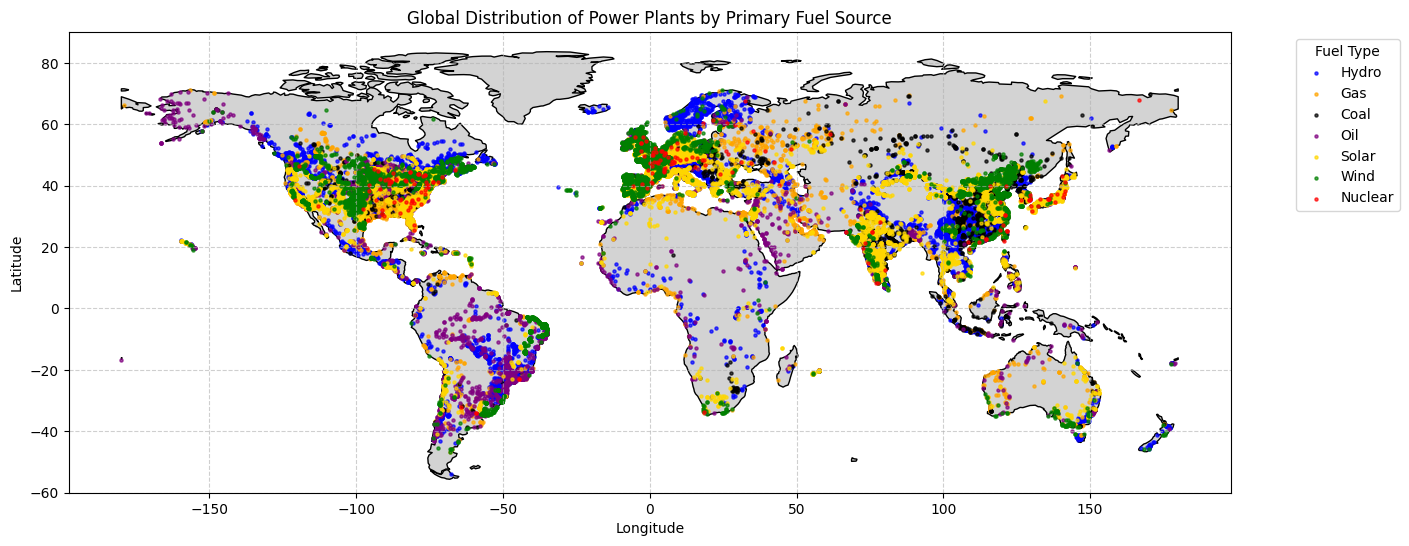

In [8]:
# Create a GeoDataFrame from the power plants data
gdf = gpd.GeoDataFrame(
    power_plants_df, 
    geometry=gpd.points_from_xy(power_plants_df.longitude, power_plants_df.latitude)
)

# Set the coordinate reference system (CRS) to WGS84
gdf.set_crs(epsg=4326, inplace=True)

# Load a world map for context using the 'naturalearth_land' dataset
# This dataset contains polygons for all landmasses.
world = gpd.read_file(geodatasets.get_path('naturalearth_land'))

# Plotting
fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, color='lightgray', edgecolor='black')

# Define a color map for the most common fuel types
fuel_colors = {
    'Hydro': 'blue',
    'Gas': 'orange',
    'Coal': 'black',
    'Oil': 'purple',
    'Solar': 'gold',
    'Wind': 'green',
    'Nuclear': 'red'
}

# Plot each fuel type with its corresponding color
for fuel, color in fuel_colors.items():
    # Filter for non-NA geometry to avoid errors
    subset = gdf[(gdf['primary_fuel'] == fuel) & (gdf.geometry.notna())]
    if not subset.empty:
        subset.plot(ax=ax, marker='o', color=color, markersize=5, label=fuel, alpha=0.7)

plt.title('Global Distribution of Power Plants by Primary Fuel Source')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
# Set map limits to avoid distortion from Antarctica
plt.ylim(-60, 90)
plt.show()

## The Reign of Coal: A Global Concern

While the map shows a diverse energy mix, fossil fuels, and particularly coal, have historically dominated. Coal is a major contributor to CO2 emissions, so let's zoom in on which countries have the largest number of coal-fired power plants.

/var/folders/lg/tqlb1wcn4nqgxx9bmgfhm3_r0000gn/T/ipykernel_12367/1085953812.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_coal_counts.values, y=country_coal_counts.index, palette='Reds_r')


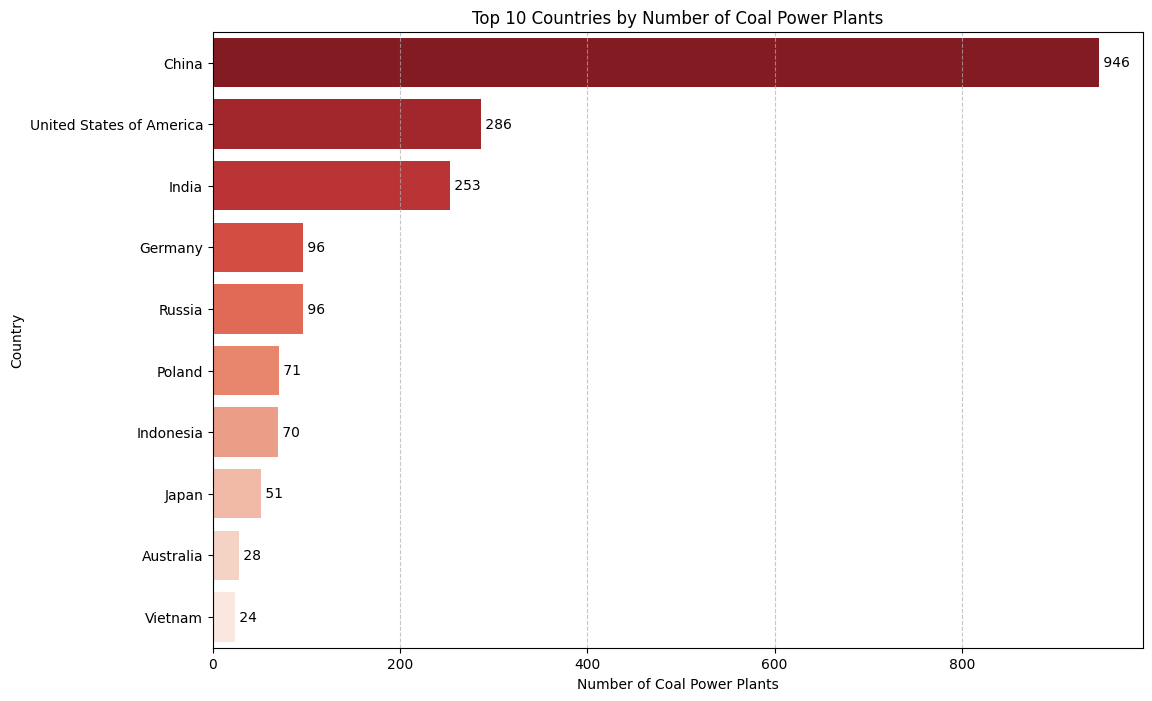

In [9]:
# Filter for coal power plants
coal_plants = power_plants_df[power_plants_df['primary_fuel'] == 'Coal'].copy()

# Group by country and count the number of coal power plants
country_coal_counts = coal_plants['country_long'].value_counts().nlargest(10)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x=country_coal_counts.values, y=country_coal_counts.index, palette='Reds_r')

plt.title('Top 10 Countries by Number of Coal Power Plants')
plt.xlabel('Number of Coal Power Plants')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add annotations to the bars
for index, value in enumerate(country_coal_counts):
    plt.text(value, index, f' {value}', va='center')

plt.show()

### Capacity, Not Just Count: A Better Metric for Impact

While the number of plants is interesting, not all plants are created equal. A more accurate measure of a country's reliance on coal is its total **generation capacity**. Let's re-run our analysis, but this time summing the capacity in megawatts (MW) to see if the ranking changes.

/var/folders/lg/tqlb1wcn4nqgxx9bmgfhm3_r0000gn/T/ipykernel_12367/1079351539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_coal_capacity.values, y=country_coal_capacity.index, palette='inferno_r')


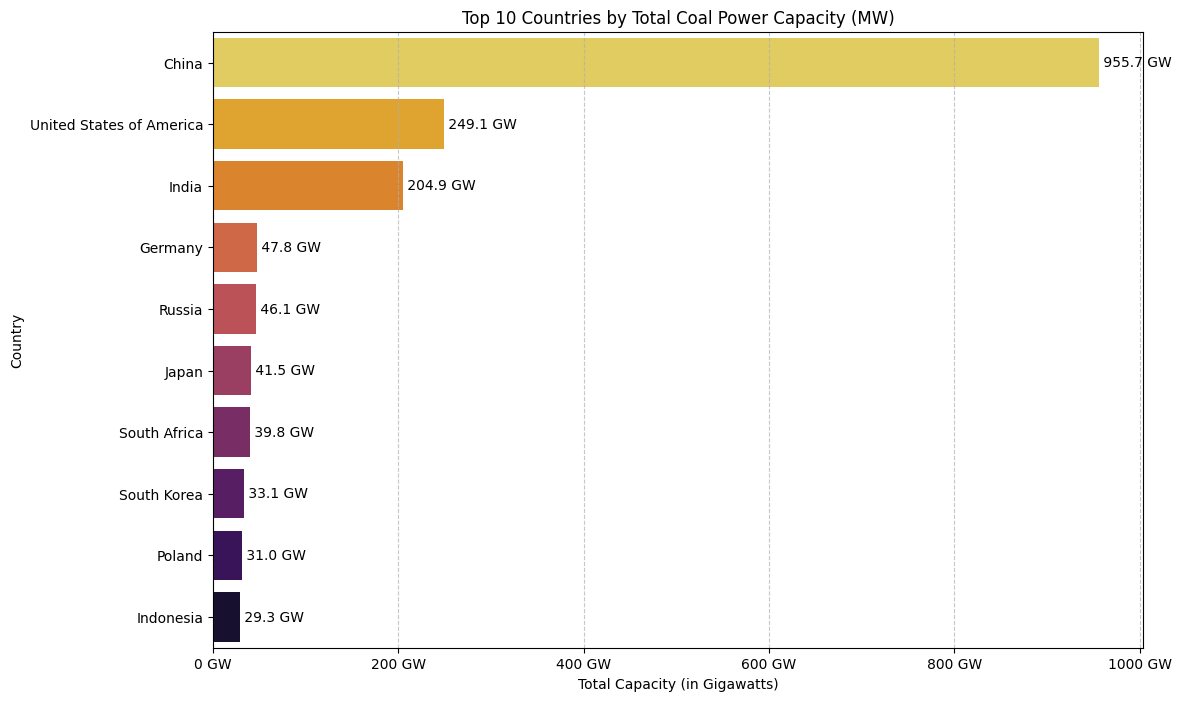

In [31]:
# Group by country and SUM the 'capacity_mw'
country_coal_capacity = coal_plants.groupby('country_long')['capacity_mw'].sum().sort_values(ascending=False).nlargest(10)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x=country_coal_capacity.values, y=country_coal_capacity.index, palette='inferno_r')

plt.title('Top 10 Countries by Total Coal Power Capacity (MW)')
plt.xlabel('Total Capacity (in Gigawatts)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Format the x-axis to be in Gigawatts (GW) for readability, since 1 GW = 1000 MW
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1000:.0f} GW'))

# Add annotations
for index, value in enumerate(country_coal_capacity):
    plt.text(value, index, f' {value/1000:.1f} GW', va='center')

plt.show()

## The U.S. Story: Emissions Under the Microscope

The global view shows that the United States has a significant number of coal power plants. To understand their environmental impact, we need more than just their location; we need to look at their emissions. For this, we'll turn to the detailed hourly emissions data from the U.S. Environmental Protection Agency (EPA).

Our goal is to identify which coal plants are the most and least efficient in terms of CO2 emissions. We'll define "efficiency" as the amount of CO2 emitted per megawatt (MW) of electricity generated. A lower value means a "cleaner" or more efficient plant. Let's dig in.

In [ ]:
# Filter emissions_df for coal-fired units.
# We use str.contains('Coal', na=False) to catch different types like "Bituminous Coal".
coal_emissions_df = emissions_df[emissions_df['Primary Fuel Type'].str.contains('Coal', case=False, na=False)].copy()

# Clean the data: We need positive power generation to calculate a meaningful emission rate.
# Filter out rows where 'Gross Load (MW)' is zero or negative, or where CO2 data is missing.
valid_data_mask = (coal_emissions_df['Gross Load (MW)'] > 0) & (coal_emissions_df['CO2 Mass (short tons)'].notna())
coal_emissions_df_filtered = coal_emissions_df[valid_data_mask].copy()

# Calculate CO2 emissions per MW for each hourly record.
coal_emissions_df_filtered.loc[:, 'CO2_per_MW'] = coal_emissions_df_filtered['CO2 Mass (short tons)'] / coal_emissions_df_filtered['Gross Load (MW)']

# To get a stable measure of performance, we'll average the hourly rates for each facility.
facility_co2_performance = coal_emissions_df_filtered.groupby(['Facility Name', 'State'])['CO2_per_MW'].mean().reset_index()

# Find the plant with the lowest and highest average CO2 per MW.
cleanest_plant = facility_co2_performance.loc[facility_co2_performance['CO2_per_MW'].idxmin()]
most_pollutant_plant = facility_co2_performance.loc[facility_co2_performance['CO2_per_MW'].idxmax()]

# Print the results
print("--- Cleanest vs. Most Pollutant U.S. Coal Plants (Q1 2024) ---")
print("\nCleanest Plant (Lowest Average CO2 per MW):")
print(f"  Facility Name: {cleanest_plant['Facility Name']}")
print(f"  State: {cleanest_plant['State']}")
print(f"  Average CO2 Mass per MW: {cleanest_plant['CO2_per_MW']:.4f} short tons")

print("\nMost Pollutant Plant (Highest Average CO2 per MW):")
print(f"  Facility Name: {most_pollutant_plant['Facility Name']}")
print(f"  State: {most_pollutant_plant['State']}")
print(f"  Average CO2 Mass per MW: {most_pollutant_plant['CO2_per_MW']:.4f} short tons")

--- Cleanest vs. Most Pollutant U.S. Coal Plants (Q1 2024) ---

Cleanest Plant (Lowest Average CO2 per MW):
  Facility Name: Apache Station
  State: AZ
  Average CO2 Mass per MW: 0.6573 short tons

Most Pollutant Plant (Highest Average CO2 per MW):
  Facility Name: Centralia
  State: WA
  Average CO2 Mass per MW: 11.2822 short tons


## Visualizing the Efficiency Spectrum

The numbers show a dramatic difference between the cleanest and most polluting plants. But where do all the other plants fall? A histogram will help us visualize the distribution of CO2 efficiency across all U.S. coal plants in the dataset. This gives us a better sense of whether the top and bottom performers are outliers or representative of broader trends.

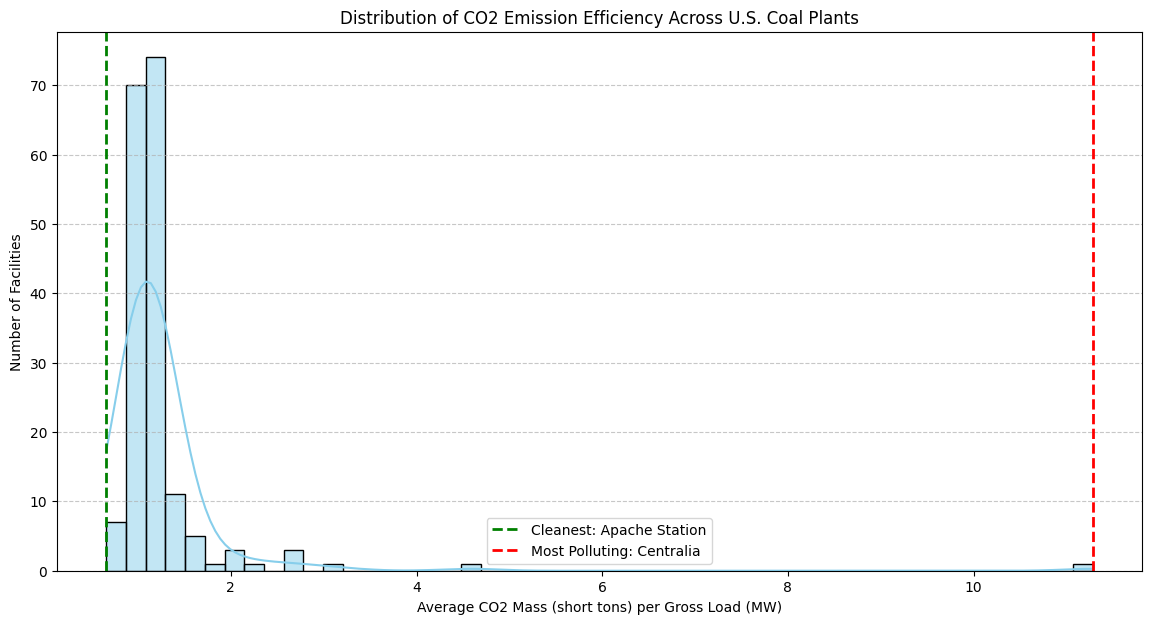

In [11]:
plt.figure(figsize=(14, 7))

# Plot a histogram of the average CO2 per MW for all facilities
sns.histplot(facility_co2_performance['CO2_per_MW'], bins=50, kde=True, color='skyblue')

# Add vertical lines to mark our specific plants of interest
plt.axvline(cleanest_plant['CO2_per_MW'], color='green', linestyle='--', linewidth=2, label=f"Cleanest: {cleanest_plant['Facility Name']}")
plt.axvline(most_pollutant_plant['CO2_per_MW'], color='red', linestyle='--', linewidth=2, label=f"Most Polluting: {most_pollutant_plant['Facility Name']}")

plt.title('Distribution of CO2 Emission Efficiency Across U.S. Coal Plants')
plt.xlabel('Average CO2 Mass (short tons) per Gross Load (MW)')
plt.ylabel('Number of Facilities')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Always On? A Look at Plant Operating Time

A plant's total impact isn't just about its emission rate; it's also about how often it's running. The EPA dataset includes an "Operating Time" column, which represents the fraction of an hour a unit was active (e.g., a value of 1.0 means it ran for the full hour).

Does this uptime vary by state? Let's analyze the average operating time for coal plants across the country to see which states run their plants most consistently.

/var/folders/lg/tqlb1wcn4nqgxx9bmgfhm3_r0000gn/T/ipykernel_12367/1003638993.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.values, y=comparison_df.index, palette=colors)


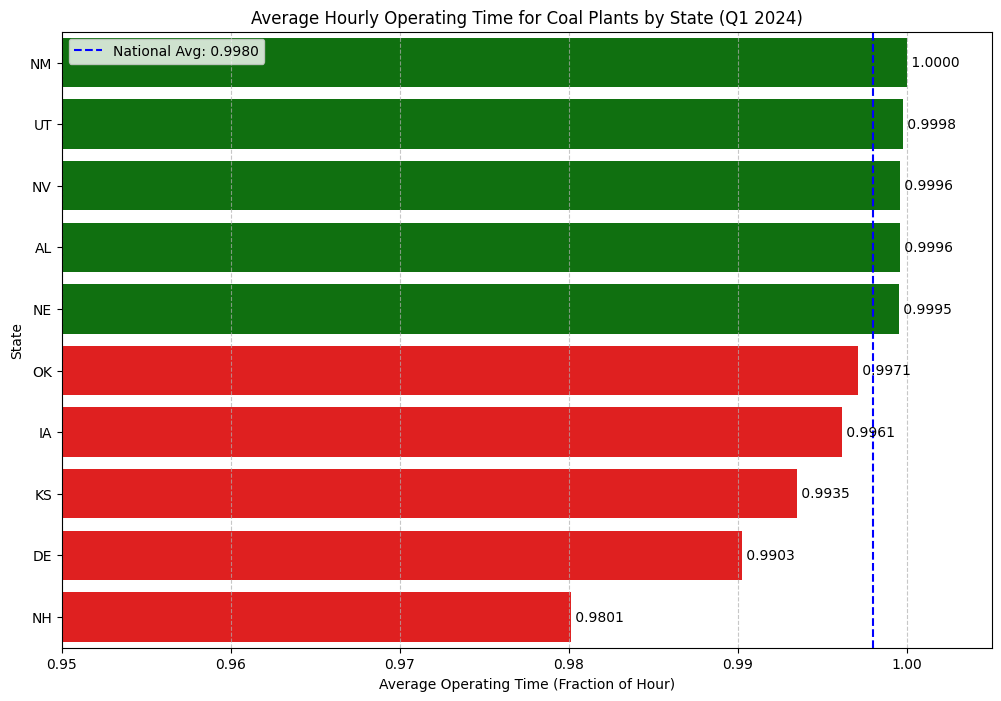

In [12]:
# Calculate the average operating time by state
state_avg_operating_time = coal_emissions_df_filtered.groupby('State')['Operating Time'].mean().sort_values(ascending=False)

# Get the top 5 and bottom 5 states for a more focused visualization
top_5_states = state_avg_operating_time.head(5)
bottom_5_states = state_avg_operating_time.tail(5)
comparison_df = pd.concat([top_5_states, bottom_5_states])

# Create the plot
plt.figure(figsize=(12, 8))
colors = ['green'] * 5 + ['red'] * 5
sns.barplot(x=comparison_df.values, y=comparison_df.index, palette=colors)

plt.title('Average Hourly Operating Time for Coal Plants by State (Q1 2024)')
plt.xlabel('Average Operating Time (Fraction of Hour)')
plt.ylabel('State')
plt.xlim(0.95, 1.005) # Set x-axis limits to emphasize the differences
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add annotations
for index, value in enumerate(comparison_df):
    plt.text(value, index, f' {value:.4f}', va='center')

plt.axvline(x=state_avg_operating_time.mean(), color='blue', linestyle='--', label=f'National Avg: {state_avg_operating_time.mean():.4f}')
plt.legend()
plt.show()

## State of Emissions: Who's on Top?

While uptime gives us a sense of plant activity, the most critical question is about the bottom line: which states produce the most CO2 from coal? Here, we'll aggregate the total mass of CO2 emissions for each state from the first quarter of 2024.

/var/folders/lg/tqlb1wcn4nqgxx9bmgfhm3_r0000gn/T/ipykernel_12367/247695014.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_states_co2.values, y=top_10_states_co2.index, palette='inferno')


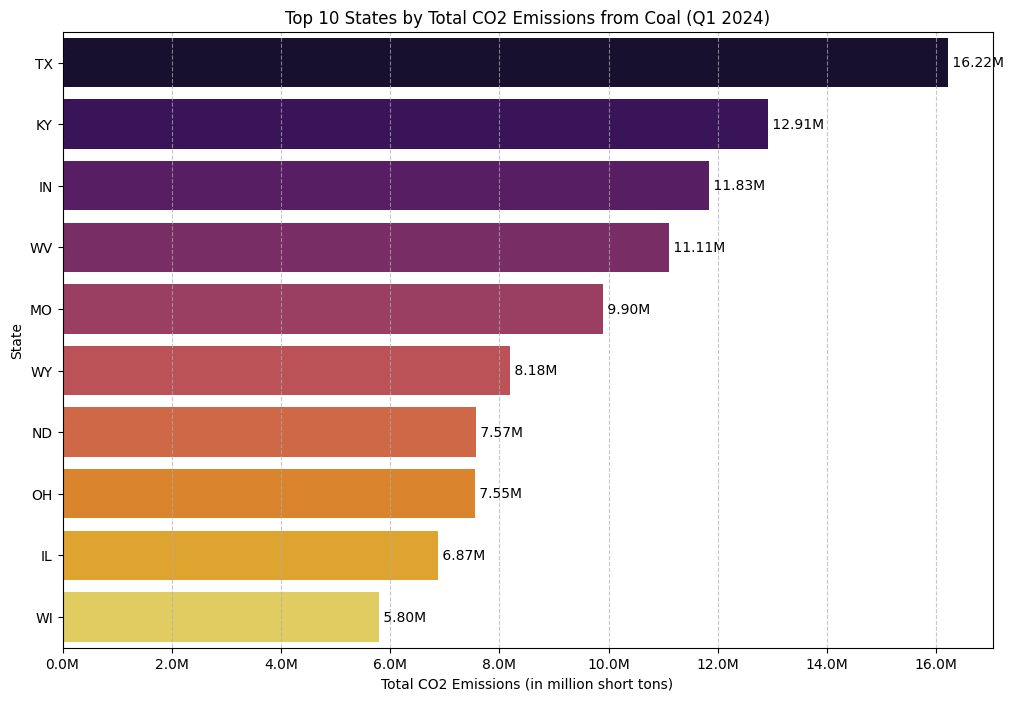

In [14]:
# Group by state and sum the total CO2 emissions
state_total_co2 = coal_emissions_df_filtered.groupby('State')['CO2 Mass (short tons)'].sum().sort_values(ascending=False)

# Get the top 10 states
top_10_states_co2 = state_total_co2.nlargest(10)

# Create the plot
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_states_co2.values, y=top_10_states_co2.index, palette='inferno')

plt.title('Top 10 States by Total CO2 Emissions from Coal (Q1 2024)')
plt.xlabel('Total CO2 Emissions (in million short tons)')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Format the x-axis to be in millions of tons for readability
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M'))

# Add annotations
for index, value in enumerate(top_10_states_co2):
    plt.text(value, index, f' {value/1_000_000:.2f}M', va='center')

plt.show()

In [ ]:
# Data Preparation
# Start with the dataframe that is only filtered for coal, not for gross load.
# This ensures we keep the "Off" records (where Gross Load is 0 or NaN).
base_emissions_for_modeling = emissions_df[emissions_df['Primary Fuel Type'].str.contains('Coal', case=False, na=False)].copy()

# Create a clean DataFrame with plant locations
plant_locations = power_plants_df[['name', 'latitude', 'longitude']].drop_duplicates(subset=['name'])

# Merge to add coordinates
hourly_data_with_coords = pd.merge(
    base_emissions_for_modeling,
    plant_locations,
    left_on='Facility Name',
    right_on='name',
    how='inner'
)

# Select our two plants for the modeling exercise
plant_names_to_model = ["Barry", "Gorgas"]
base_df = hourly_data_with_coords[hourly_data_with_coords['Facility Name'].isin(plant_names_to_model)].copy()
print(f"Found {len(base_df)} hourly records (both on and off) for modeling.")

# Google Earth Engine Function
def get_recent_swir_feature(lat, lon, date_str, window_days=14):
    try:
        point = ee.Geometry.Point(lon, lat)
        end_date = ee.Date(date_str).advance(1, 'day')
        start_date = end_date.advance(-window_days, 'day')
        image_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                           .filterBounds(point)
                           .filterDate(start_date, end_date)
                           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))
        if image_collection.size().getInfo() == 0: return None
        best_image = image_collection.sort('CLOUDY_PIXEL_PERCENTAGE').first()
        roi = point.buffer(500)
        stats = best_image.select('B11').reduceRegion(
            reducer=ee.Reducer.mean(), geometry=roi, scale=20
        ).get('B11')
        return stats.getInfo()
    except Exception as e:
        return None

# Feature Calculation
unique_plant_days = base_df[['Facility Name', 'Date', 'latitude', 'longitude']].drop_duplicates().copy()
print(f"Found {len(unique_plant_days)} unique plant-days to process for satellite features.")

from tqdm.auto import tqdm
satellite_features = []
for index, row in tqdm(unique_plant_days.iterrows(), total=unique_plant_days.shape[0], desc="Fetching Satellite Features"):
    feature = get_recent_swir_feature(row['latitude'], row['longitude'], row['Date'])
    satellite_features.append(feature)

unique_plant_days['satellite_feature'] = satellite_features

# Merge the features back to create the final modeling dataframe
model_df = pd.merge(
    base_df,
    unique_plant_days[['Facility Name', 'Date', 'satellite_feature']],
    on=['Facility Name', 'Date'],
    how='left'
)

# Clean the final dataset
model_df.dropna(subset=['satellite_feature'], inplace=True)
print(f"\nCreated final modeling dataset with {len(model_df)} records.")

Found 2184 hourly records (both on and off) for modeling.
Found 91 unique plant-days to process for satellite features.


Fetching Satellite Features: 100%|██████████| 91/91 [02:08<00:00,  1.41s/it]


Created final modeling dataset with 336 records.


## Model 1: Predicting CO2 Emissions with Linear Regression

Our first challenge is to predict the *amount* of CO2 being emitted. We'll build a simple linear regression model where:

*   **Feature (X):** The `satellite_feature` (our SWIR band value).
*   **Target (y):** The hourly `CO2 Mass (short tons)`.

For this model, we **must** filter the data again to only include records where the plant was actually running (`Gross Load (MW) > 0`), since predicting emissions for an "Off" plant doesn't make sense.

Using 91 records for the regression model (only 'On' states).
Model Coefficient: -0.0205
A negative coefficient suggests that a lower SWIR value correlates with higher CO2 emissions.


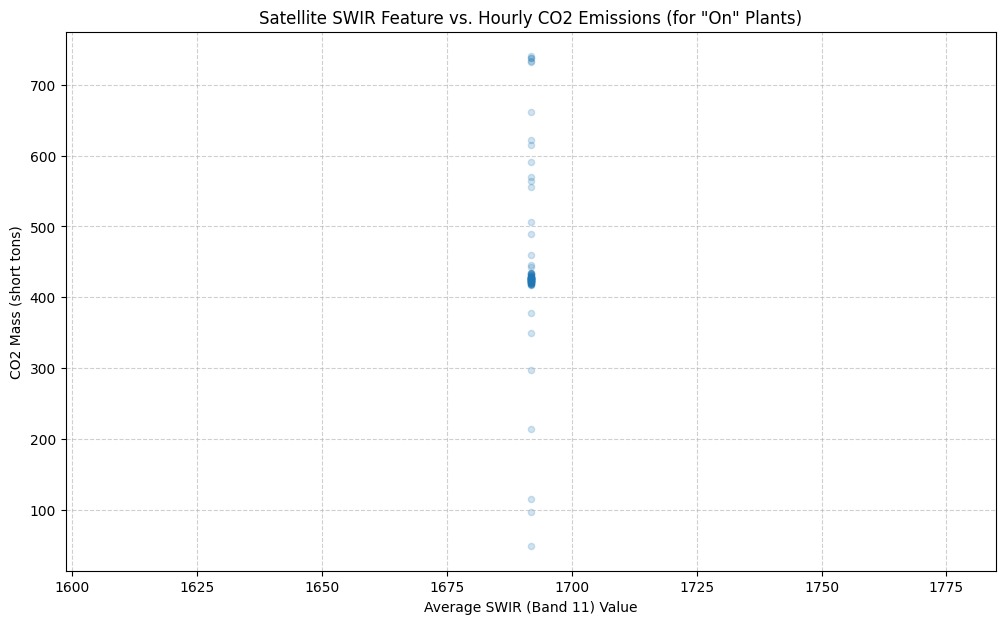

In [ ]:
# For regression, we only use data where the plant is ON and emitting.
reg_df = model_df[(model_df['Gross Load (MW)'] > 0) & (model_df['CO2 Mass (short tons)'].notna())].copy()
print(f"Using {len(reg_df)} records for the regression model (only 'On' states).")

# Define features (X) and target (y)
X_reg = reg_df[['satellite_feature']]
y_reg = reg_df['CO2 Mass (short tons)']

# Initialize and train the model
regression_model = LinearRegression()
regression_model.fit(X_reg, y_reg)

# Print the model's coefficient
print(f"Model Coefficient: {regression_model.coef_[0]:.4f}")
print("A negative coefficient suggests that a lower SWIR value correlates with higher CO2 emissions.")

# Visualize the relationship
plt.figure(figsize=(12, 7))
sns.regplot(x='satellite_feature', y='CO2 Mass (short tons)', data=reg_df,
            scatter_kws={'alpha':0.2, 's':20},
            line_kws={'color':'red', 'linewidth':2})

plt.title('Satellite SWIR Feature vs. Hourly CO2 Emissions (for "On" Plants)')
plt.xlabel('Average SWIR (Band 11) Value')
plt.ylabel('CO2 Mass (short tons)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Model 2: Predicting On/Off Status with Logistic Regression

Now for our classification task. We will use the **full `model_df` dataset**, which contains both "On" and "Off" states.

*   **Feature (X):** The `satellite_feature`.
*   **Target (y):** A new `on_off_status` column. If `Operating Time > 0`, the plant is "On" (1). Otherwise, it's "Off" (0).

Let's see how well a **Logistic Regression** model can distinguish between these two states.

Class distribution for the classification model:
on_off_status
0    244
1     92
Name: count, dtype: int64

Classification Model Accuracy: 72.62%


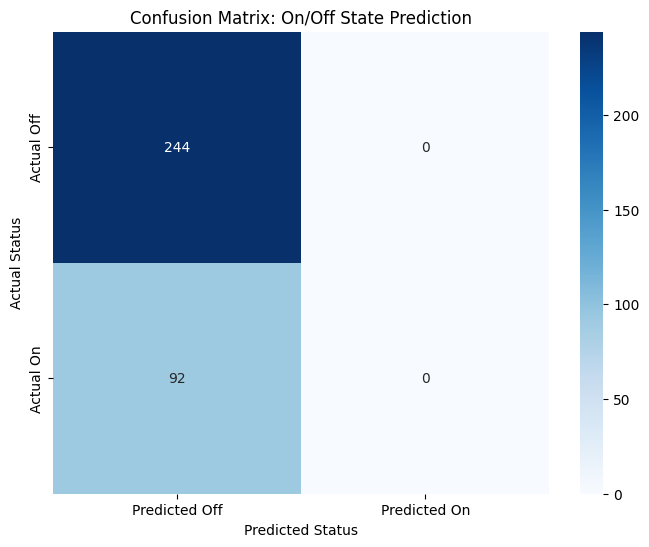

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Prepare the data for classification using the full model_df
clf_df = model_df.copy()
clf_df['on_off_status'] = (clf_df['Operating Time'] > 0).astype(int)

# Check the class distribution to confirm we have both classes
print("Class distribution for the classification model:")
print(clf_df['on_off_status'].value_counts())

# Define features (X) and target (y)
X_clf = clf_df[['satellite_feature']]
y_clf = clf_df['on_off_status']

# Initialize and train the logistic regression model
classification_model = LogisticRegression()
classification_model.fit(X_clf, y_clf)

# Make predictions
predictions = classification_model.predict(X_clf)
accuracy = accuracy_score(y_clf, predictions)
print(f"\nClassification Model Accuracy: {accuracy:.2%}")

# Use a confusion matrix to see what we got right and what we got wrong.
cm = confusion_matrix(y_clf, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Off', 'Predicted On'],
            yticklabels=['Actual Off', 'Actual On'])
plt.title('Confusion Matrix: On/Off State Prediction')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

##  Reality Check: Accuracy Isn't Enough

Our first attempt at modeling gave us a fascinating and very real-world result. The regression model struggled to find a pattern, and the classification model, despite a promising 72.6% accuracy, was cheating! The confusion matrix revealed that the model had simply learned to always predict "Off," the most common state in our dataset. It wasn't using the satellite data to make an intelligent decision.

This is a valuable lesson: a high accuracy score can be misleading. A model is only useful if it learns the underlying patterns in the data.

So, we go back to the drawing board. Our initial feature—the raw SWIR value—was too simple. We need to engineer more sophisticated features that provide a clearer signal of a power plant's activity. Let's try two new approaches:

1.  **The SWIR Anomaly:** Instead of the raw value, we'll measure how much "hotter" or "brighter" a plant looks compared to its own normal "Off" state. This *relative change* should be a much stronger indicator of activity than the absolute value.
2.  **A Direct Pollutant Measurement (NO₂):** We will bring in data from a different satellite, Sentinel-5P, which is designed to monitor air quality. We can measure the concentration of Nitrogen Dioxide (NO₂)—a key pollutant from burning fuel—directly over the power plant. A spike in NO₂ is a direct signature of combustion.

With these two powerful new features, let's see if we can build a model that genuinely learns.

In [ ]:
# Define a new GEE function for Sentinel-5P NO2 data
def get_daily_no2_feature(lat, lon, date_str):
    """Fetches the mean NO2 concentration from Sentinel-5P for a given day."""
    try:
        point = ee.Geometry.Point(lon, lat)
        date = ee.Date(date_str)
        image_collection = (ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2')
                           .filterBounds(point)
                           .filterDate(date, date.advance(1, 'day')))
        image = image_collection.first()
        if not image: return None
        no2_band = image.select('NO2_column_number_density')
        roi = point.buffer(5000)
        stats = no2_band.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=roi, scale=1000
        ).get('NO2_column_number_density')
        return stats.getInfo()
    except Exception as e:
        return None

# Engineer the New Features

# 1. Get unique days from our hourly modeling dataframe
unique_days_df = model_df[['Facility Name', 'Date', 'latitude', 'longitude', 'satellite_feature']].drop_duplicates().copy()

# 2. Calculate a "baseline" SWIR for each plant using its median "off" value
model_df['on_off_status'] = (model_df['Operating Time'] > 0).astype(int)
off_states_df = model_df[model_df['on_off_status'] == 0]
baseline_swir = off_states_df.groupby('Facility Name')['satellite_feature'].median().to_dict()
print("Calculated Baseline SWIR values (when off):")
print(baseline_swir)

# 3. Map the baseline to our unique days and calculate the anomaly
unique_days_df['baseline_swir'] = unique_days_df['Facility Name'].map(baseline_swir)
unique_days_df['swir_anomaly'] = unique_days_df['satellite_feature'] - unique_days_df['baseline_swir']

# 4. Fetch the NO2 feature for each unique day
from tqdm.auto import tqdm
no2_features = []
for index, row in tqdm(unique_days_df.iterrows(), total=unique_days_df.shape[0], desc="Fetching NO2 Features"):
    feature = get_daily_no2_feature(row['latitude'], row['longitude'], row['Date'])
    no2_features.append(feature)
unique_days_df['no2_concentration'] = no2_features

# 5. Create the final, enhanced modeling dataframe by merging the new daily features back to the hourly data
enhanced_model_df = pd.merge(
    model_df,
    unique_days_df[['Facility Name', 'Date', 'swir_anomaly', 'no2_concentration']],
    on=['Facility Name', 'Date'],
    how='left'
)

# 6. Clean the data: drop rows where we couldn't get a valid feature
# This happens if a plant had no "off" state (no baseline) or if GEE failed.
enhanced_model_df.dropna(subset=['swir_anomaly', 'no2_concentration'], inplace=True)
print(f"\nCreated enhanced modeling dataset with {len(enhanced_model_df)} records.")

Calculated Baseline SWIR values (when off):
{'Barry': 1691.788358273937}


Fetching NO2 Features: 100%|██████████| 14/14 [00:23<00:00,  1.67s/it]


Created enhanced modeling dataset with 48 records.


Class distribution for the enhanced model:
on_off_status
0    28
1    20
Name: count, dtype: int64

Enhanced Classification Model Accuracy: 91.67%


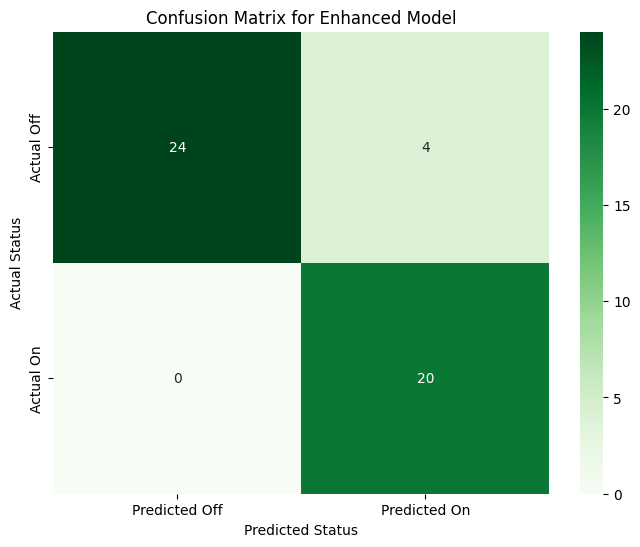

In [28]:
# Prepare the final dataframe for classification
clf_df_enhanced = enhanced_model_df.copy()

# Check the new class distribution
print("Class distribution for the enhanced model:")
print(clf_df_enhanced['on_off_status'].value_counts())

# Define features (X) and target (y)
X_clf_enhanced = clf_df_enhanced[['swir_anomaly', 'no2_concentration']]
y_clf_enhanced = clf_df_enhanced['on_off_status']

# It's good practice to scale features before logistic regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clf_enhanced)

# Initialize and train the model
classification_model_enhanced = LogisticRegression()
classification_model_enhanced.fit(X_scaled, y_clf_enhanced)

# Make predictions
predictions_enhanced = classification_model_enhanced.predict(X_scaled)
accuracy_enhanced = accuracy_score(y_clf_enhanced, predictions_enhanced)
print(f"\nEnhanced Classification Model Accuracy: {accuracy_enhanced:.2%}")

# Generate the new confusion matrix
cm_enhanced = confusion_matrix(y_clf_enhanced, predictions_enhanced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_enhanced, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Off', 'Predicted On'],
            yticklabels=['Actual Off', 'Actual On'])
plt.title('Confusion Matrix for Enhanced Model')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

### Unpacking the Success: Which Feature Was More Important?

Our enhanced model worked brilliantly, but which of our two new features did the model find more useful? For a logistic regression model, we can inspect the **model coefficients**. These numbers tell us how the model "weighs" each feature when making a decision. A larger coefficient (either positive or negative) means the feature has a stronger influence on the outcome.

/var/folders/lg/tqlb1wcn4nqgxx9bmgfhm3_r0000gn/T/ipykernel_12367/3706021534.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df.values, y=feature_importance_df.index, palette='viridis')


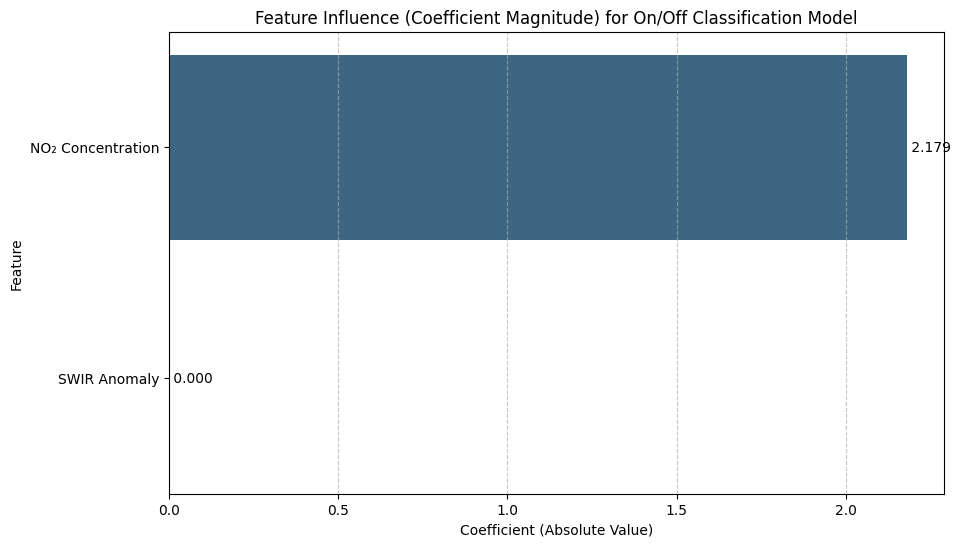

Model Coefficients:
  SWIR Anomaly: 0.0000
  NO₂ Concentration: -2.1792

A positive coefficient means that an increase in that feature makes the model more likely to predict 'On'.


In [34]:
# Get the coefficients from the trained Logistic Regression model
# The model stores them in the .coef_ attribute. Since it's a binary classifier, we take the first (and only) row.
coefficients = classification_model_enhanced.coef_[0]
feature_names = ['SWIR Anomaly', 'NO₂ Concentration']

# Create a pandas series for easy plotting. We use the absolute value for magnitude.
feature_importance_df = pd.Series(abs(coefficients), index=feature_names).sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df.values, y=feature_importance_df.index, palette='viridis')

plt.title('Feature Influence (Coefficient Magnitude) for On/Off Classification Model')
plt.xlabel('Coefficient (Absolute Value)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add annotations to the bars
for index, value in enumerate(feature_importance_df):
    plt.text(value, index, f' {value:.3f}', va='center')

plt.show()

# Print the actual coefficients to see the direction of the relationship
print("Model Coefficients:")
for name, coef in zip(feature_names, coefficients):
    print(f"  {name}: {coef:.4f}")
print("\nA positive coefficient means that an increase in that feature makes the model more likely to predict 'On'.")

## The Challenge of Predicting Emission Quantity

Our feature engineering was a success for the classification task. We built a model that can confidently tell us if a power plant is "On" or "Off". But can we push our success further? The final and most difficult challenge remains: can we predict the *quantity* of CO2 emissions?

For this, we will upgrade our modeling toolkit, using a `RandomForestRegressor`—a powerful model that can capture complex, non-linear patterns. We'll train it on our high-quality features (`swir_anomaly`, `no2_concentration`) for the hours the plants were active.

However, our rigorous data cleaning and fusion process has left us with a small, high-quality dataset of just 20 "On" events. This presents a new, critical question: do we have enough data for a model to learn such a complex relationship? Let's find out.

Using 20 'On' records for the enhanced regression model.

--- Enhanced Regression Model Results ---
R-squared (R²): -0.63
Mean Absolute Error (MAE): 135.17 short tons
Out-of-Bag Score (OOB): -0.14


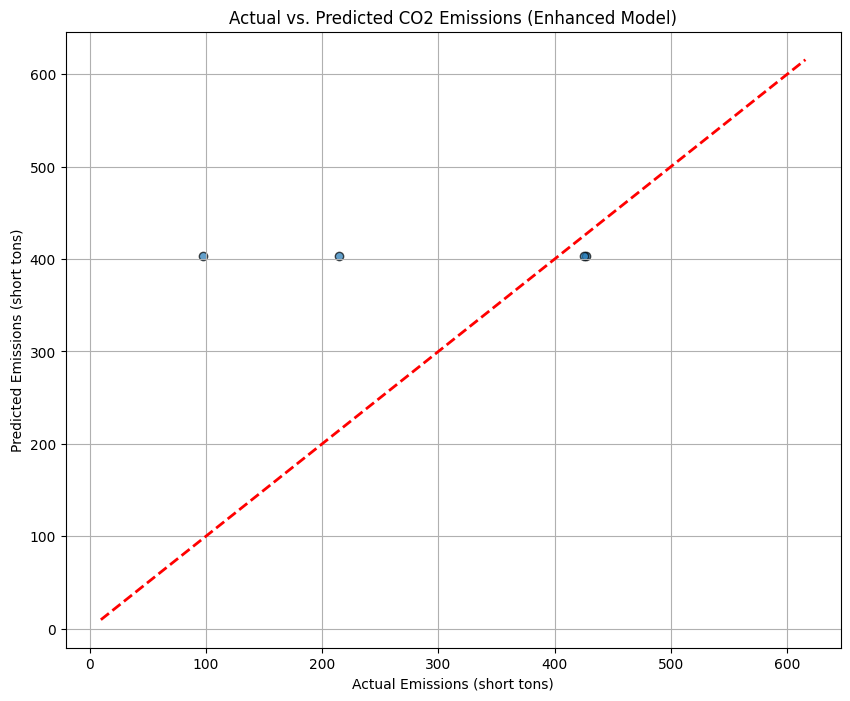

In [30]:
# 1. Prepare the data
# We use the same 'enhanced_model_df', but only for records where the plant was ON.
reg_df_enhanced = enhanced_model_df[enhanced_model_df['on_off_status'] == 1].copy()
print(f"Using {len(reg_df_enhanced)} 'On' records for the enhanced regression model.")

# 2. Define features (X) and target (y)
X = reg_df_enhanced[['swir_anomaly', 'no2_concentration']]
y = reg_df_enhanced['CO2 Mass (short tons)']

# 3. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the RandomForestRegressor model
# n_estimators is the number of trees in the forest.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
rf_model.fit(X_train, y_train)

# 5. Make predictions on the unseen test data
y_pred = rf_model.predict(X_test)

# 6. Evaluate the model's performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- Enhanced Regression Model Results ---")
print(f"R-squared (R²): {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} short tons")
print(f"Out-of-Bag Score (OOB): {rf_model.oob_score_:.2f}")

# 7. Visualize the results: Actual vs. Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # y=x line
plt.title('Actual vs. Predicted CO2 Emissions (Enhanced Model)')
plt.xlabel('Actual Emissions (short tons)')
plt.ylabel('Predicted Emissions (short tons)')
plt.grid(True)
plt.show()

### The Final Insight: Why Predicting Quantity is So Difficult

Our final regression model struggled, even with our improved features. Why? The missing piece is the plant's **hourly operational load**. A plant that is "On" is not always running at 100% capacity. Its output fluctuates based on energy demand.

This final plot shows the direct relationship between the power generated each hour (Gross Load) and the CO2 emitted. We can see a clear linear trend, but also significant variance. Our satellite features are good at detecting the "On/Off" signal, but capturing this precise, fluctuating load from space is the true frontier—a challenge that requires even more sophisticated data.

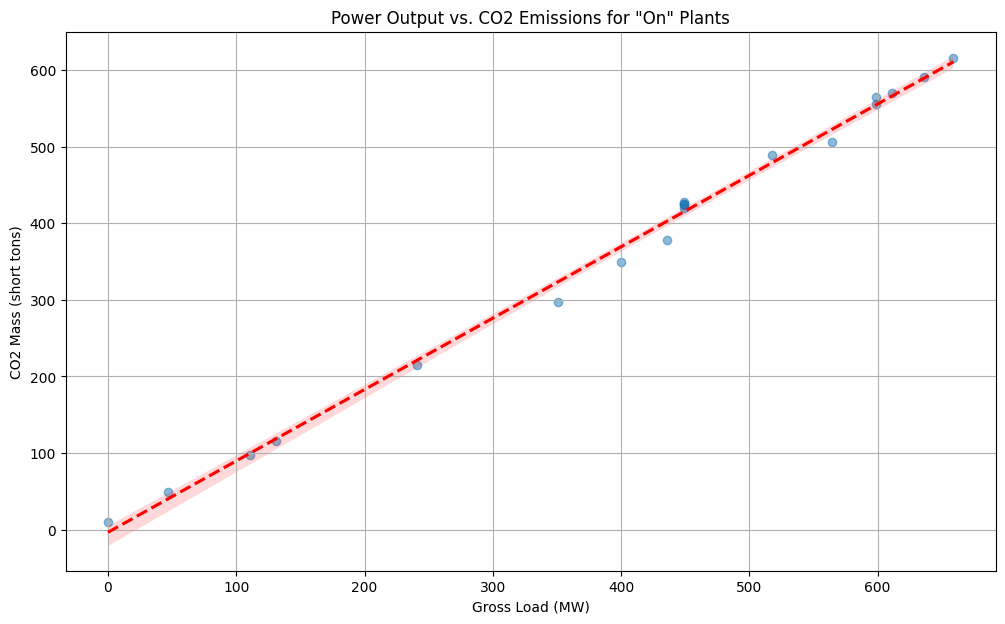

In [32]:
# Use the same dataframe from our successful regression attempt
# This contains only 'On' records with valid emissions data
on_records_df = enhanced_model_df[enhanced_model_df['on_off_status'] == 1].copy()

plt.figure(figsize=(12, 7))
sns.regplot(
    data=on_records_df,
    x='Gross Load (MW)',
    y='CO2 Mass (short tons)',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'linestyle': '--'}
)

plt.title('Power Output vs. CO2 Emissions for "On" Plants')
plt.xlabel('Gross Load (MW)')
plt.ylabel('CO2 Mass (short tons)')
plt.grid(True)
plt.show()

## Conclusion

The feature importance chart tells the entire story in a single image: the direct measurement of NO₂ pollution was overwhelmingly the most important feature, so much so that the model learned to completely ignore the more subtle thermal-infrared signal.

By incorporating data from a satellite specifically designed to monitor air quality (Sentinel-5P), we gave our model a direct, unambiguous signal of industrial activity.

The success of the classification model, driven by this single powerful feature, and the informative struggle of the regression model, constrained by a lack of data, provide our key takeaways:

*   **Go to the Source:** When possible, use data that measures your target phenomenon as directly as possible. For monitoring pollution, a chemical trace from an air-quality satellite proved far more effective than an indirect heat signature.
*   **Feature Engineering is About Signal, Not Just Cleverness:** Our "SWIR anomaly" was a good idea, but the NO₂ data provided a much cleaner signal. The best feature isn't the most complex; it's the one with the least noise.